In [1]:
!pip install torch torchvision matplotlib scikit-learn -q

In [2]:
import torch
import torchvision
from torchvision import datasets, transforms, models
from torch import nn, optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
# Data augmentation for training images
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

# Transform for test images
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load CIFAR-10 dataset
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

print("Training Images:", len(train_dataset))
print("Testing Images:", len(test_dataset))

100%|██████████| 170M/170M [00:34<00:00, 4.91MB/s]


Training Images: 50000
Testing Images: 10000


In [4]:
# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 1563
Test batches: 313


In [5]:
# Load pretrained MobileNetV2
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Change final layer for CIFAR-10 (10 classes)
model.classifier[1] = nn.Linear(model.last_channel, 10)

print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 219MB/s]

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [6]:
from torch.utils.data import Subset

# Small subset for faster training
train_subset = Subset(train_dataset, range(5000))
test_subset = Subset(test_dataset, range(1000))

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False
)

print("Train Images:", len(train_subset))
print("Test Images:", len(test_subset))

Train Images: 5000
Test Images: 1000


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 2  # fast training for submission

train_losses = []
train_accuracies = []

In [8]:
for epoch in range(epochs):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.2f}%")

Epoch [1/2] Loss: 0.8856 Accuracy: 70.54%
Epoch [2/2] Loss: 0.5065 Accuracy: 82.78%


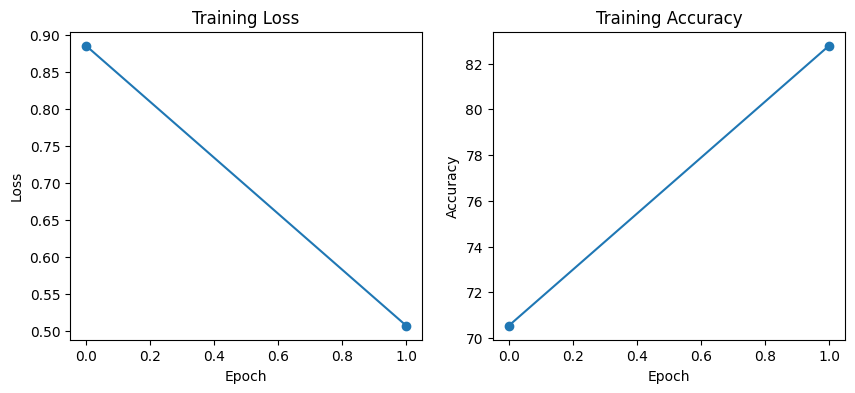

In [9]:
plt.figure(figsize=(10,4))

# Loss graph
plt.subplot(1,2,1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy graph
plt.subplot(1,2,2)
plt.plot(train_accuracies, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

In [10]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))

Test Accuracy: 0.755

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.77      0.73       103
           1       0.97      0.80      0.88        89
           2       0.53      0.88      0.66       100
           3       0.61      0.71      0.66       103
           4       0.70      0.57      0.63        90
           5       0.80      0.64      0.71        86
           6       0.85      0.82      0.84       112
           7       0.97      0.58      0.72       102
           8       0.92      0.79      0.85       106
           9       0.80      0.94      0.87       109

    accuracy                           0.76      1000
   macro avg       0.79      0.75      0.75      1000
weighted avg       0.79      0.76      0.76      1000



In [11]:
torch.save(model.state_dict(), "mobilenetv2_cifar10.pth")
print("Model saved successfully!")

Model saved successfully!


In [12]:
import numpy as np

model.eval()

# take one batch from test loader
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

print("Predictions:", preds[:10].cpu().numpy())
print("Actual Labels:", labels[:10].numpy())

Predictions: [3 8 8 0 6 6 1 2 3 1]
Actual Labels: [3 8 8 0 6 6 1 6 3 1]


In [13]:
!mkdir -p project_files
!cp mobilenetv2_cifar10.pth project_files/
print("Files ready for GitHub folder")

Files ready for GitHub folder


In [14]:
!pip install fastapi uvicorn nest-asyncio pyngrok -q

In [15]:
from fastapi import FastAPI
import nest_asyncio
import uvicorn
import torch

app = FastAPI()

model.eval()

@app.get("/")
def home():
    return {"message": "CIFAR10 Model API is running"}

@app.get("/predict")
def predict():
    images, labels = next(iter(test_loader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    return {
        "predictions": preds[:5].cpu().numpy().tolist()
    }

nest_asyncio.apply()

In [17]:
from pyngrok import ngrok
import uvicorn


In [18]:
!uvicorn main:app --host 0.0.0.0 --port 8000 &

ERROR:    Error loading ASGI app. Could not import module "main".


In [19]:
from fastapi import FastAPI

app = FastAPI()

@app.get("/")
def home():
    return {"message": "API working fine"}

In [20]:
!pip install uvicorn nest-asyncio pyngrok -q

In [23]:
import os
print(os.listdir())

['.config', 'mobilenetv2_cifar10.pth', 'project_files', 'data', 'sample_data']


In [24]:
from google.colab import files

files.download("mobilenetv2_cifar10.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>